In [1]:
import pandas as pd
df = pd.read_csv("/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv")

In [2]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [3]:
df.dropna(subset=["created_year"],inplace = True)

In [4]:
df.isna().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    120
Abbreviation                               120
channel_type                                27
video_views_rank                             0
country_rank                               114
channel_type_rank                           29
video_views_for_the_last_30_days            51
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               332
created_year                                 0
created_month                                0
created_date 

In [5]:
years = df["created_year"].unique()
years

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 1970., 2019.,
       2022.])

In [6]:
# drop the outlier 1970 (impossible )
df.drop(df[df["created_year"] == years[-3]].index, inplace=True)

In [7]:
df["created_year"].unique()

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 2019., 2022.])

In [8]:
# create the column complete_date by combinng the columns created date , month and year , using time series method in pandas
df["created_complete_date"] = pd.to_datetime(df["created_year"].astype(int).astype(str) 
                                             + "-" + df["created_month"].astype(str) 
                                             + "-" + df["created_date"].astype(int).astype(str) ,
                                             format="%Y-%b-%d" ,dayfirst=False).apply(lambda x: x.strftime("%Y"))

In [9]:
df["created_complete_date"]

0      2006
1      2006
2      2012
3      2006
4      2006
       ... 
990    2017
991    2018
992    2006
993    2012
994    2017
Name: created_complete_date, Length: 989, dtype: object

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

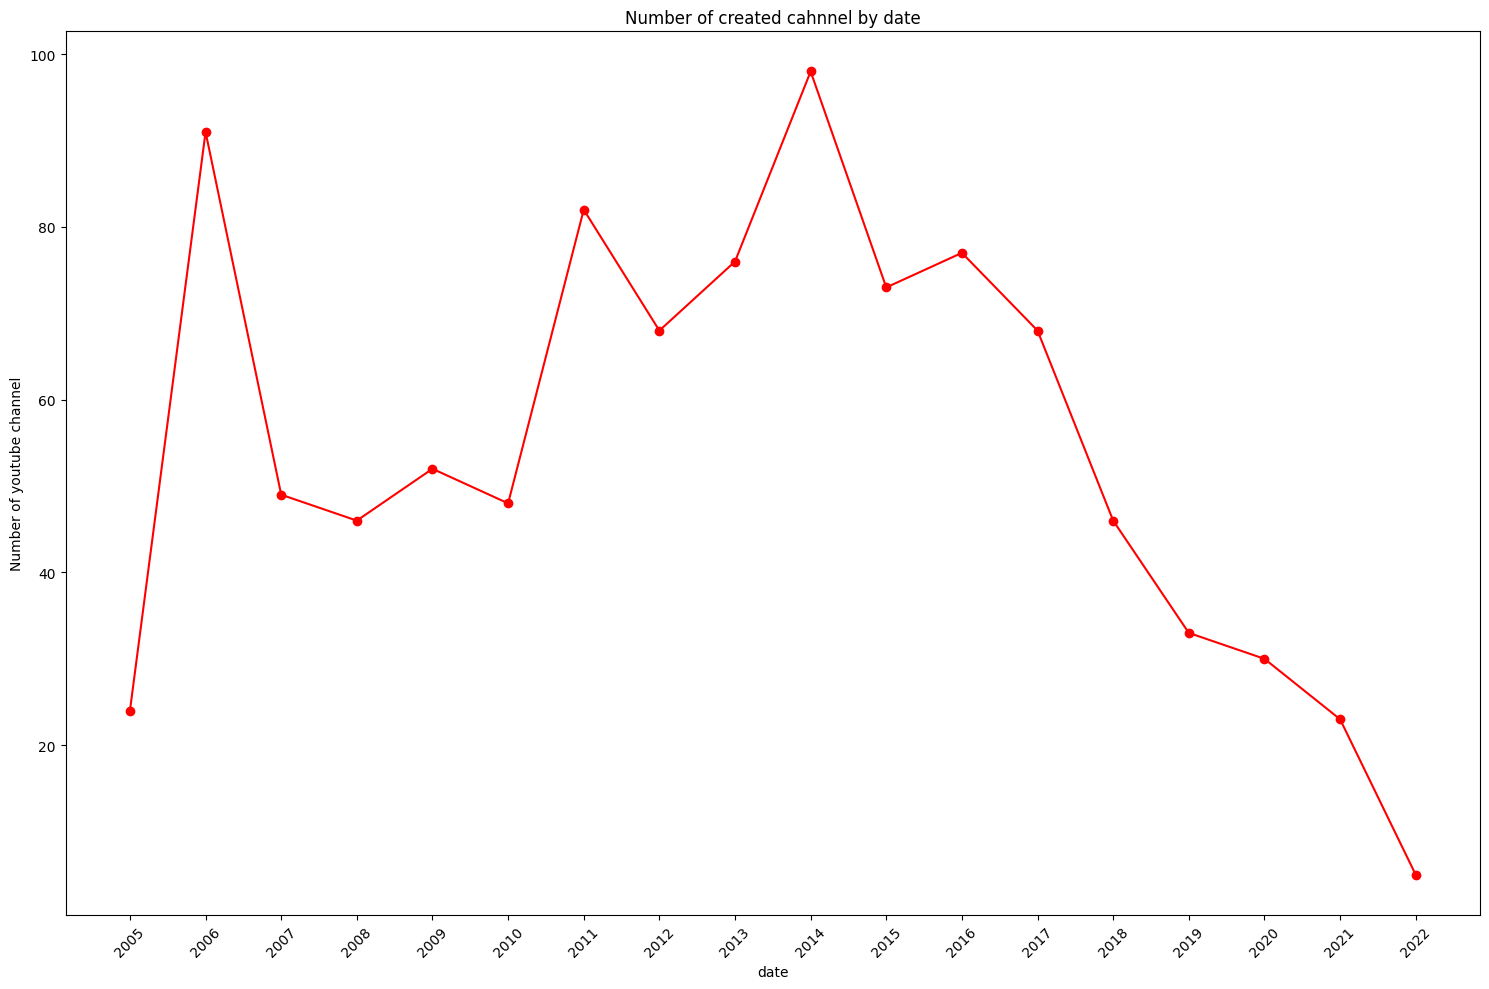

In [11]:
grouped = df.groupby("created_complete_date")["Youtuber"].count()

x = list(grouped.index)
y = list(grouped.values)
w = list(df.groupby("channel_type")["video_views_for_the_last_30_days"].sum()/1e9)

plt.figure(figsize=(15, 10))
plt.plot(x, y , marker='o', linestyle='-', color='r')
plt.title("Number of created cahnnel by date")
plt.xlabel("date")
plt.ylabel("Number of youtube channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

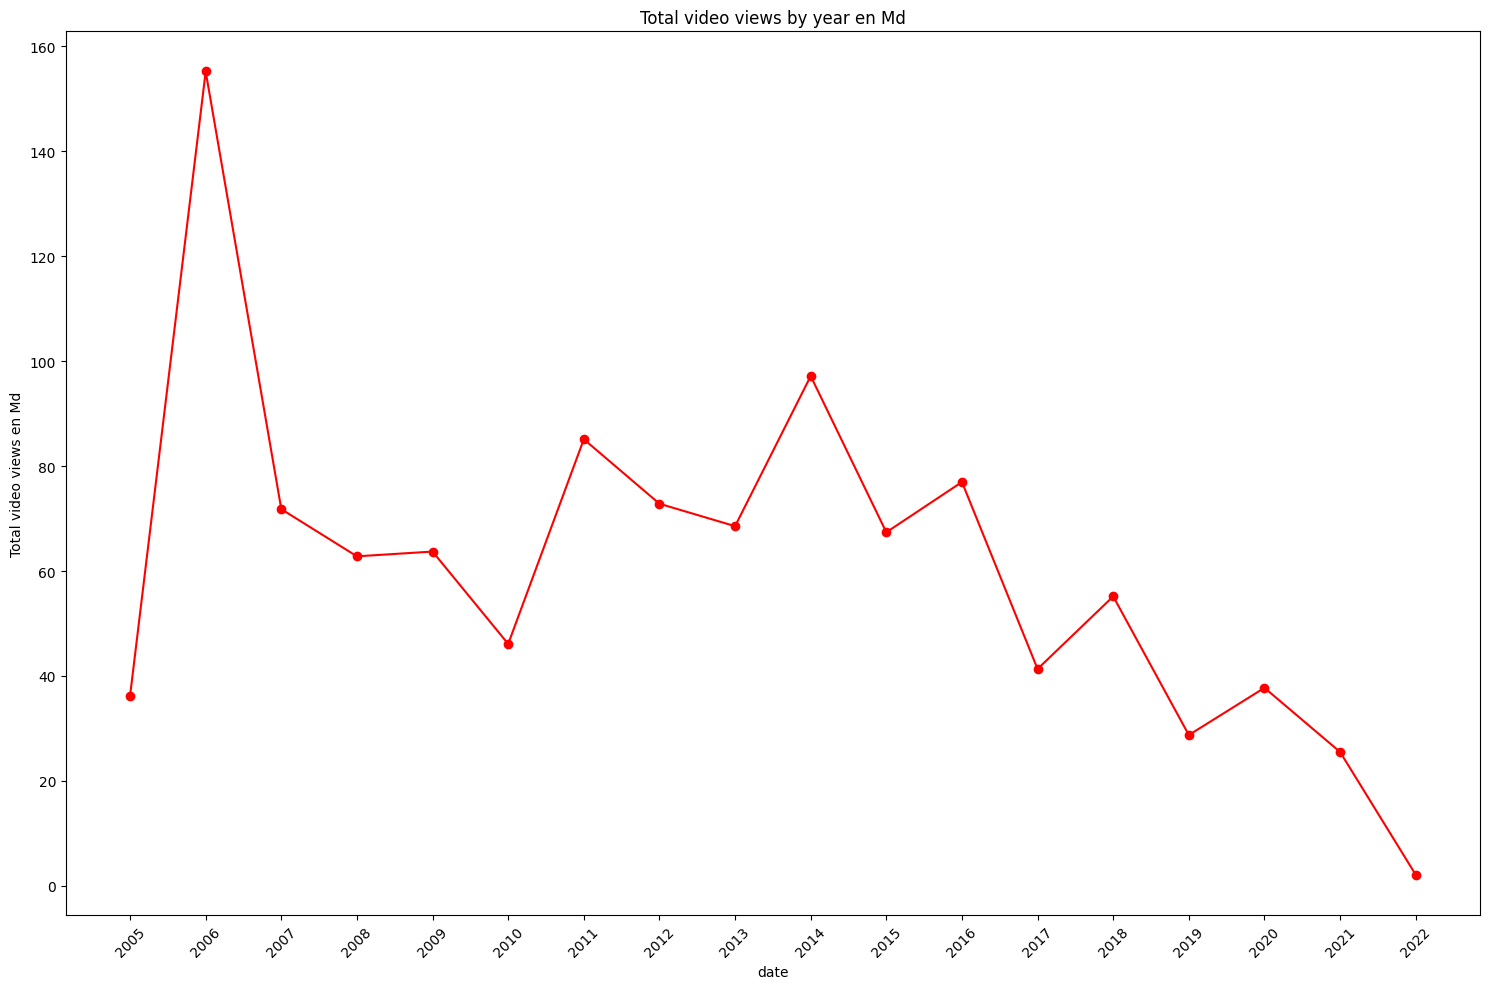

In [12]:
grouped = df.groupby("created_complete_date")["video views"].sum().apply(lambda x : x /1e10)

x = list(grouped.index)
y = list(grouped.values)

plt.figure(figsize=(15, 10))
plt.plot(x, y , marker='o', linestyle='-', color='r')
plt.title("Total video views by year en Md")
plt.xlabel("date")
plt.ylabel("Total video views en Md")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
## on remarque que les chaines les plus anciens genere un nombre enorme des video views en comparaison avec les chaines les plus recentes.

In [14]:
df.dropna(subset=["Latitude","Longitude","Country"] , inplace =True)


In [15]:
grouped = df.groupby("Country" ,as_index=False).agg({
    "video views" : "sum",
    "Latitude" : lambda x : x.mode().iloc[0] ,
    "Longitude" : lambda x : x.mode().iloc[0]
}).sort_values(by="video views" , ascending=False)

grouped.head()


,Country,video views,Latitude,Longitude
45,United States,3.681592e+12,37.090240,-95.712891
17,India,2.281048e+12,20.593684,78.962880
5,Brazil,4.787683e+11,-14.235004,-51.925280
44,United Kingdom,4.305665e+11,55.378051,-3.435973
40,Thailand,2.643180e+11,15.870032,100.992541


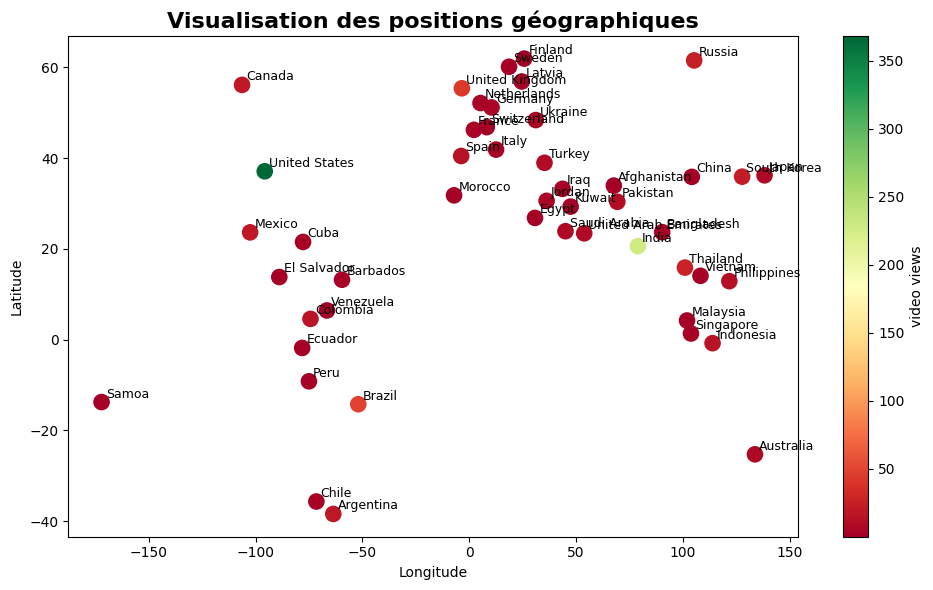

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

scatter = ax.scatter(
    grouped["Longitude"], grouped["Latitude"],
    c=grouped["video views"] / 1e10,
    s=120,
    cmap="RdYlGn"
)

for i in range(len(grouped)):
    ax.text(
        grouped.iloc[i]["Longitude"] + 2,
        grouped.iloc[i]["Latitude"] + 1,
        grouped.iloc[i]["Country"],
        fontsize=9
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("video views")

ax.set_title("Visualisation des positions géographiques", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

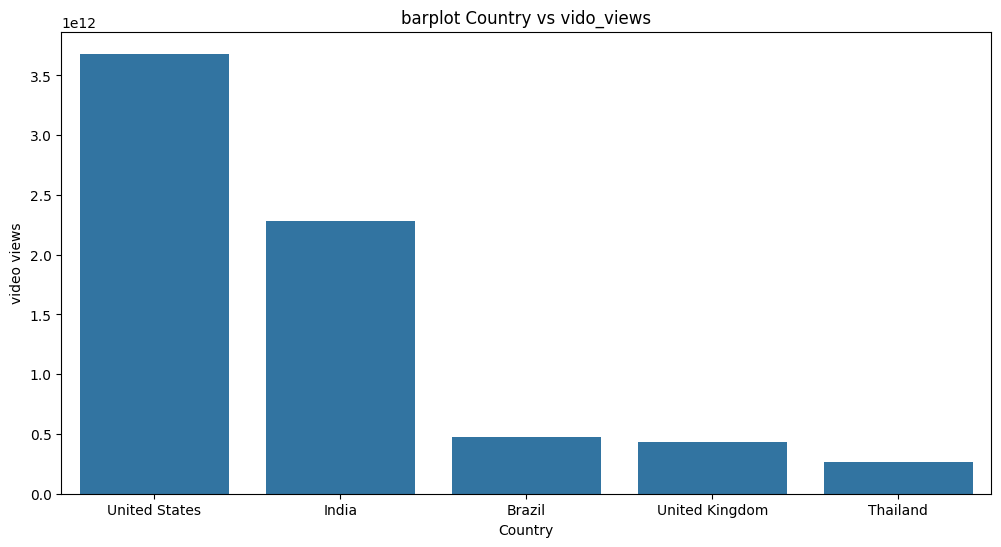

In [17]:
#bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x="Country",y="video views",data=grouped.iloc[:5])
plt.title("barplot Country vs vido_views")
plt.show()

In [ ]:
import geopandas as gpd
import geodatasets
from shapely.geometry import LineString


/home/umoujahid/anaconda3/envs/mouja_ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


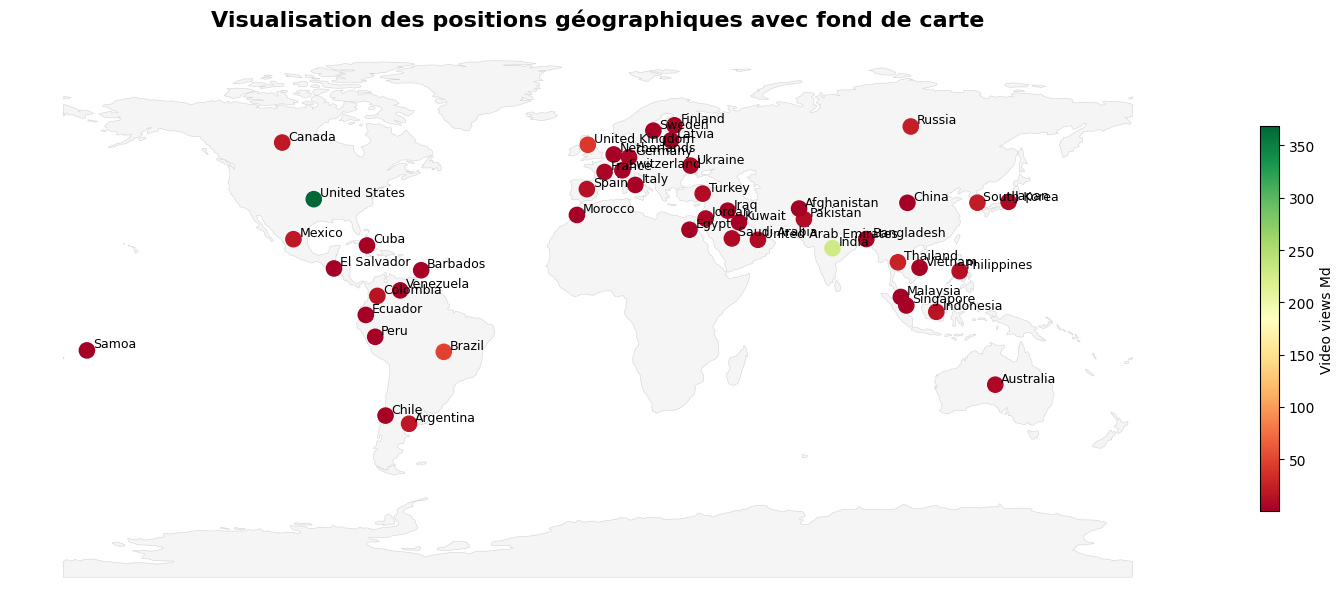

In [19]:
#Conversion en GeoDataFrame
gdf = gpd.GeoDataFrame(
    grouped,
    geometry=gpd.points_from_xy(grouped["Longitude"], grouped["Latitude"]),
    crs="EPSG:4326"
)
#Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

#Visualisation avec fond de carte
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# points
scatter = ax.scatter(
    gdf["Longitude"], gdf["Latitude"], c=gdf["video views"]/1e10,
    s=120,
    cmap="RdYlGn" 
 )

# noms des villes
for i in range(len(gdf)):
    ax.text(
        gdf.iloc[i] ["Longitude"] + 2,
        gdf.iloc[i] ["Latitude"] + 1,
        gdf.iloc[i] ["Country"],
        fontsize=9
    )

# barre de couleur
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Video views Md")

ax.set_title("Visualisation des positions géographiques avec fond de carte", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()



Colonnes disponibles dans le fond de carte :
Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)

Données fusionnées :
                         ADMIN   video views
0                         Fiji           NaN
1  United Republic of Tanzania           NaN
2               Western Sahara           NaN
3                       Canada  1.913206e+11
4     United States of America           NaN


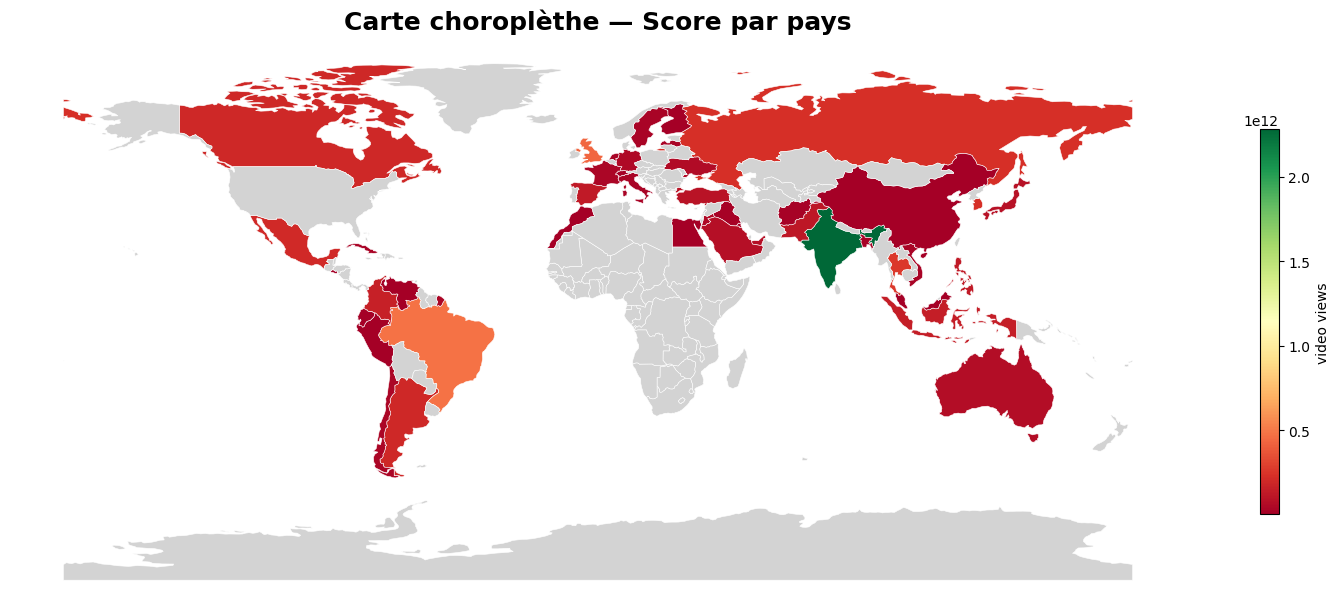

In [24]:
# Fichier Natural Earth (pays du monde)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

print("\nColonnes disponibles dans le fond de carte :")
print(world.columns)

# Fusion des données
# Dans ce jeu, le nom du pays est dans la colonne 'ADMIN'
world_merged = world.merge(grouped, left_on="ADMIN", right_on="Country", how="left")

print("\nDonnées fusionnées :")
print(world_merged[["ADMIN", "video views"]].head())

# Visualisation choroplèthe
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_merged.plot(
    column="video views",
    ax=ax,
    cmap="RdYlGn",
    legend=True,
    legend_kwds={
        "label": "video views",
        "orientation": "vertical",
        "shrink": 0.5
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Pas de données"
    },
    edgecolor="white",
    linewidth=0.4
)

ax.set_title("Carte choroplèthe — Score par pays", fontsize=18, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()